In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as nc

In [4]:
import xarray as xr
import numpy as np

# ---------------------------
# 1. read GRIDMET data
# ---------------------------
grid_path = "../.data/GRIDMET/gridmet_4km_jja_ne/tmmx_JJA_NE_2000_2025.nc"
ds_grid = xr.open_dataset(grid_path)

print(ds_grid)
print(ds_grid.lat.values[:5], ds_grid.lat.values[-5:])
print(ds_grid.lon.values[:5], ds_grid.lon.values[-5:])

# ---------------------------
# 2. read ETOPO2 topo
# ---------------------------
topo_path = "../.data/ETOPO2/ETOPO2v2c_f4.nc"
ds_topo = xr.open_dataset(topo_path)

# z is the elevation variable
topo = ds_topo["z"]

# rename coordinates to match GRIDMET style
topo = topo.rename({"x": "lon", "y": "lat"})

topo

<xarray.Dataset> Size: 1GB
Dimensions:          (day: 2392, lat: 240, lon: 311, crs: 1)
Coordinates:
  * day              (day) datetime64[ns] 19kB 2000-06-01 ... 2025-08-31
  * lat              (lat) float64 2kB 46.98 46.94 46.9 ... 37.11 37.07 37.03
  * lon              (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.1 -67.06
  * crs              (crs) uint16 2B 3
Data variables:
    air_temperature  (day, lat, lon) float64 1GB ...
[46.98333333 46.94166667 46.9        46.85833333 46.81666667] [37.19166667 37.15       37.10833333 37.06666667 37.025     ]
[-79.97499997 -79.9333333  -79.89166663 -79.84999997 -79.8083333 ] [-67.22499997 -67.1833333  -67.14166663 -67.09999997 -67.0583333 ]


<xarray.DataArray 'z' (lat: 5400, lon: 10800)> Size: 233MB
[58320000 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 22kB -89.98 -89.95 -89.92 ... 89.92 89.95 89.98
  * lon      (lon) float32 43kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    long_name:     z
    actual_range:  [-10791.   8440.]

In [5]:
# ---------------------------
# 3. subset topo to GRIDMET domain (+ small buffer)
# ---------------------------
lat_min = float(ds_grid.lat.min())
lat_max = float(ds_grid.lat.max())
lon_min = float(ds_grid.lon.min())
lon_max = float(ds_grid.lon.max())

buffer_deg = 0.2  # small buffer around domain

topo_sub = topo.sel(
    lat=slice(lat_min - buffer_deg, lat_max + buffer_deg),
    lon=slice(lon_min - buffer_deg, lon_max + buffer_deg)
)

print(topo_sub)

<xarray.DataArray 'z' (lat: 311, lon: 399)> Size: 496kB
[124089 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 1kB 36.85 36.88 36.92 36.95 ... 47.12 47.15 47.18
  * lon      (lon) float32 2kB -80.15 -80.12 -80.08 ... -66.95 -66.92 -66.88
Attributes:
    long_name:     z
    actual_range:  [-10791.   8440.]


In [6]:
from scipy.ndimage import generic_filter, maximum_filter, minimum_filter

# ---------------------------
# 4. derive topo features on original topo grid
# ---------------------------
z = topo_sub.values.astype(np.float32)

lat = topo_sub["lat"].values
lon = topo_sub["lon"].values

# approximate grid spacing in meters
dlat = float(np.mean(np.diff(lat)))
dlon = float(np.mean(np.diff(lon)))
lat0 = float(np.mean(lat))

dy = 111_000.0 * abs(dlat)
dx = 111_000.0 * np.cos(np.deg2rad(lat0)) * abs(dlon)

# gradients
dz_dy, dz_dx = np.gradient(z, dy, dx)

# slope magnitude
slope = np.sqrt(dz_dx**2 + dz_dy**2).astype(np.float32)

# aspect
aspect = np.arctan2(dz_dy, -dz_dx).astype(np.float32)
aspect_sin = np.sin(aspect).astype(np.float32)
aspect_cos = np.cos(aspect).astype(np.float32)

# terrain roughness: local std in 5x5 window
roughness = generic_filter(z, np.std, size=5).astype(np.float32)

# local relief: local max - local min in 5x5 window
local_relief = (maximum_filter(z, size=5) - minimum_filter(z, size=5)).astype(np.float32)

ds_topo_feat = xr.Dataset(
    data_vars={
        "elevation": (("lat", "lon"), z),
        "slope": (("lat", "lon"), slope),
        "aspect_sin": (("lat", "lon"), aspect_sin),
        "aspect_cos": (("lat", "lon"), aspect_cos),
        "roughness": (("lat", "lon"), roughness),
        "local_relief": (("lat", "lon"), local_relief),
    },
    coords={
        "lat": topo_sub["lat"],
        "lon": topo_sub["lon"],
    },
)

print(ds_topo_feat)

<xarray.Dataset> Size: 3MB
Dimensions:       (lat: 311, lon: 399)
Coordinates:
  * lat           (lat) float32 1kB 36.85 36.88 36.92 ... 47.12 47.15 47.18
  * lon           (lon) float32 2kB -80.15 -80.12 -80.08 ... -66.92 -66.88
Data variables:
    elevation     (lat, lon) float32 496kB 368.0 384.0 358.0 ... 504.0 494.0
    slope         (lat, lon) float32 496kB 0.007251 0.001898 ... 0.01939 0.01662
    aspect_sin    (lat, lon) float32 496kB 0.5964 0.2849 ... 0.9478 0.9757
    aspect_cos    (lat, lon) float32 496kB -0.8027 0.9586 ... -0.3189 0.2189
    roughness     (lat, lon) float32 496kB 43.75 46.84 39.34 ... 64.24 33.46
    local_relief  (lat, lon) float32 496kB 166.0 182.0 182.0 ... 196.0 104.0


In [ ]:

# 5. interpolate derived topo features to GRIDMET grid
# ---------------------------
ds_topo_on_gridmet = ds_topo_feat.interp(
    lat=ds_grid.lat,
    lon=ds_grid.lon,
    method="linear"
)

print(ds_topo_on_gridmet)

<xarray.Dataset> Size: 4MB
Dimensions:       (lat: 240, lon: 311)
Coordinates:
  * lat           (lat) float64 2kB 46.98 46.94 46.9 46.86 ... 37.11 37.07 37.03
  * lon           (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.14 -67.1 -67.06
Data variables:
    elevation     (lat, lon) float64 597kB 310.5 313.0 ... -4.99e+03 -4.993e+03
    slope         (lat, lon) float64 597kB 0.007208 0.005208 ... 0.001168
    aspect_sin    (lat, lon) float64 597kB 0.3048 -0.2964 ... 0.03571 0.1739
    aspect_cos    (lat, lon) float64 597kB 0.4464 -0.862 ... 0.09201 -0.3793
    roughness     (lat, lon) float64 597kB 21.17 19.06 17.74 ... 9.593 7.95
    local_relief  (lat, lon) float64 597kB 76.0 71.0 66.0 ... 44.5 43.75 37.37


In [8]:
# Create a land mask from the GRIDMET dataset
# If a grid cell has at least one valid value over time, treat it as land
land_mask = ds_grid["air_temperature"].notnull().any(dim="day")

# Apply the same land mask to the interpolated topography
# Ocean grid cells will be set to NaN
ds_topo_on_gridmet_masked = ds_topo_on_gridmet.where(land_mask)

ds_topo_on_gridmet_masked

<xarray.Dataset> Size: 4MB
Dimensions:       (lat: 240, lon: 311)
Coordinates:
  * lat           (lat) float64 2kB 46.98 46.94 46.9 46.86 ... 37.11 37.07 37.03
  * lon           (lon) float64 2kB -79.97 -79.93 -79.89 ... -67.14 -67.1 -67.06
Data variables:
    elevation     (lat, lon) float64 597kB nan nan nan nan ... nan nan nan nan
    slope         (lat, lon) float64 597kB nan nan nan nan ... nan nan nan nan
    aspect_sin    (lat, lon) float64 597kB nan nan nan nan ... nan nan nan nan
    aspect_cos    (lat, lon) float64 597kB nan nan nan nan ... nan nan nan nan
    roughness     (lat, lon) float64 597kB nan nan nan nan ... nan nan nan nan
    local_relief  (lat, lon) float64 597kB nan nan nan nan ... nan nan nan nan

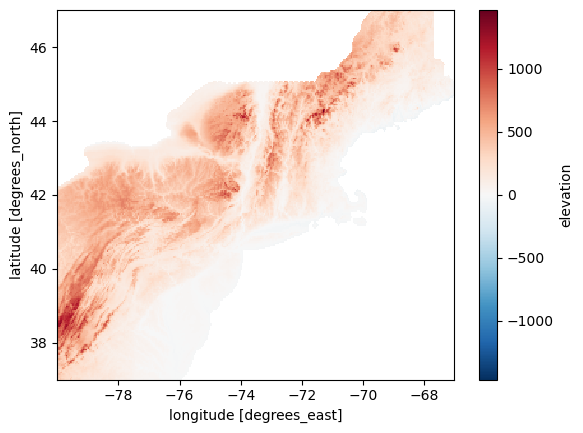

In [ ]:
ds_topo_on_gridmet_masked.elevation.plot()

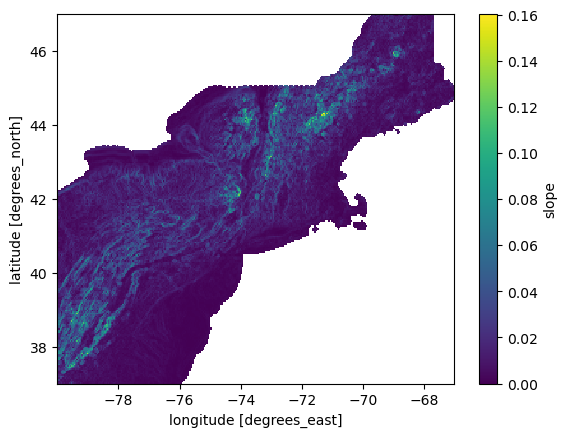

In [12]:
ds_topo_on_gridmet_masked.slope.plot()


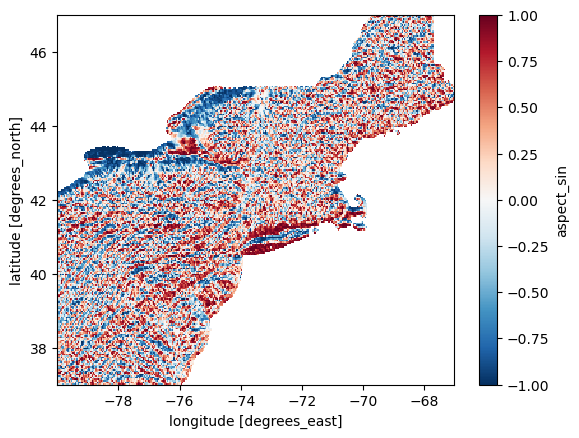

In [13]:
ds_topo_on_gridmet_masked.aspect_sin.plot()


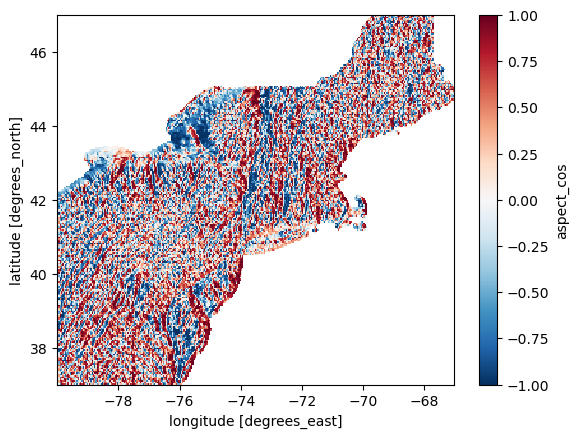

In [14]:
ds_topo_on_gridmet_masked.aspect_cos.plot()


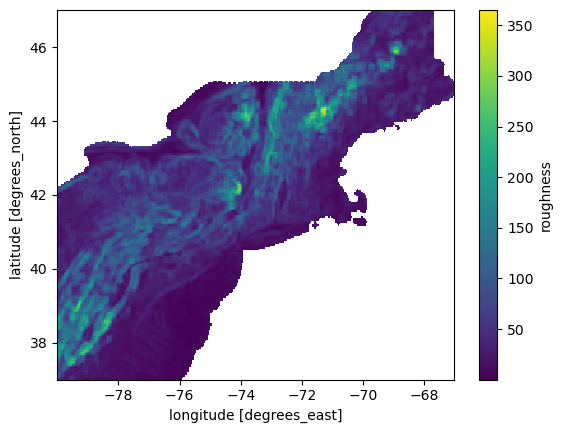

In [15]:
ds_topo_on_gridmet_masked.roughness.plot()


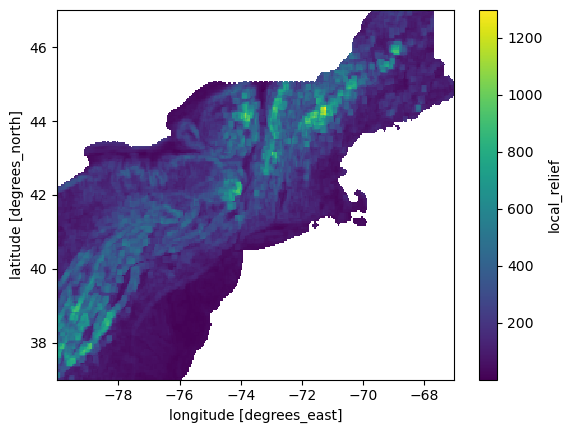

In [16]:
ds_topo_on_gridmet_masked.local_relief.plot()

In [17]:
topo_feat_path = "../.data/ETOPO2/topography_features_on_gridmet_masked.nc"
ds_topo_on_gridmet_masked.to_netcdf(topo_feat_path)
print(f"Saved {topo_feat_path}")

Saved ../.data/ETOPO2/topography_features_on_gridmet_masked.nc
